# Construction of B model

## Base model
$$
\mu_t = c + \sum_{j = 1}^p \alpha_j \log S_{t-j} + \beta^T x_t
$$


## Model B: Jump Model

$$
\log S_t=\mu_t+\eta_t+
x_t u_t
$$

$$
u_t \sim \mathrm{Bernoulli}(p_t)
$$

$$
\log \frac{p_t}{1-p_t} = \gamma_0 + \sum_{j=1}^p \gamma_j \log S_{t-j} + \omega^T z_t
$$

In [1]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside jepx-data-analytics.")
PROJECT_DIR = REPO_ROOT / "study_with_me"
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn
import statsmodels
import seaborn

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib", matplotlib.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)
print("seaborn:", seaborn.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib 3.10.8
scipy: 1.17.1
sklearn: 1.8.0
statsmodels: 0.14.6
seaborn: 0.13.2


In [2]:
train = pd.read_csv(
    (PROJECT_DATA_DIR / "model/electricity/train.csv"),
    parse_dates=["datetime"],
    index_col="datetime",
)

test = pd.read_csv(
    (PROJECT_DATA_DIR / "model/electricity/test.csv"),
    parse_dates=["datetime"],
    index_col="datetime",
)

In [3]:
train.head()

,slot,is_holiday,price,price_scaled,u,x,date,temp,tmin,tmax,...,temp_cold,log_price,log_price_lag1,log_price_lag2,log_price_lag3,log_price_lag4,log_price_lag5,log_price_lag6,log_price_lag7,fiscal_year
datetime,,,,,,,,,,,,,,,,,,,,,
2017-04-01 17:30:00,36,True,11.76,15.671103,0,0.0,2017-04-01,6.7,4.8,8.9,...,13.3,2.751818,2.590017,2.470639,2.494032,2.528126,2.729159,2.816436,2.743498,2017
2017-04-02 17:30:00,36,True,13.39,17.807886,0,0.0,2017-04-02,9.2,4.8,13.9,...,10.8,2.879641,2.751818,2.590017,2.470639,2.494032,2.528126,2.729159,2.816436,2017
2017-04-03 17:30:00,36,False,14.98,14.980000,0,0.0,2017-04-03,9.5,7.4,16.0,...,10.5,2.706716,2.879641,2.751818,2.590017,2.470639,2.494032,2.528126,2.729159,2017
2017-04-04 17:30:00,36,False,13.50,13.500000,0,0.0,2017-04-04,12.3,4.8,17.0,...,7.7,2.602690,2.706716,2.879641,2.751818,2.590017,2.470639,2.494032,2.528126,2017
2017-04-05 17:30:00,36,False,13.00,13.000000,0,0.0,2017-04-05,15.8,7.9,20.3,...,4.2,2.564949,2.602690,2.706716,2.879641,2.751818,2.590017,2.470639,2.494032,2017


# 閾値超過価格モデルを構築

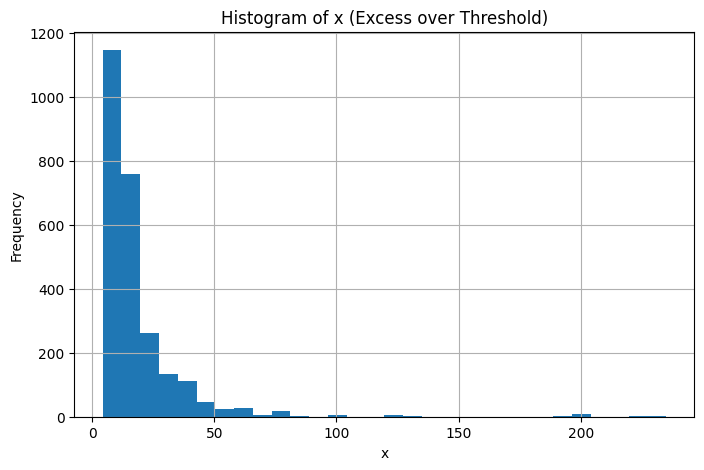

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(train["price"], bins=30)

plt.title("Histogram of x (Excess over Threshold)")
plt.xlabel("x")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

In [5]:
# ヒストリカルVaR　:要するに上位5%の価格
VaR_95 = np.percentile(train["price"], 95)
print(f"Historical VaR at 95% confidence level: {VaR_95:.2f}")

Historical VaR at 95% confidence level: 46.19


In [6]:
# ヒストリカル条件付き期待値CVaR　:要するに上位5%の価格の平均
CVaR_95 = train.loc[train["price"] > VaR_95, "price"].mean()
print(f"Historical CVaR at 95% confidence level: {CVaR_95:.2f}")

Historical CVaR at 95% confidence level: 79.88


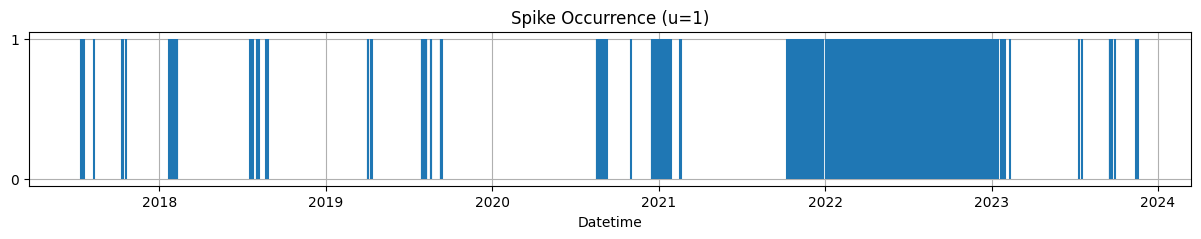

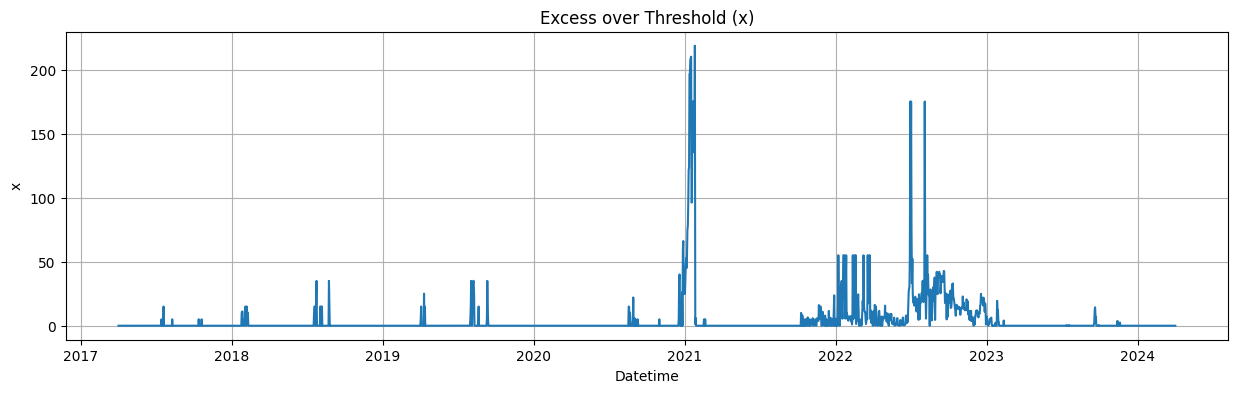

In [7]:
import matplotlib.pyplot as plt

# -------------------------
# u : スパイク発生時刻を可視化
# -------------------------
spike_times = train.index[train["u"] == 1]

plt.figure(figsize=(15, 2))

# スパイク発生箇所に縦線
plt.vlines(
    spike_times,
    ymin=0,
    ymax=1,
)

plt.title("Spike Occurrence (u=1)")
plt.xlabel("Datetime")
plt.yticks([0, 1])
plt.grid(True)

plt.show()


# -------------------------
# x : 閾値超過量
# -------------------------
plt.figure(figsize=(15, 4))

plt.plot(train.index, train["x"])

plt.title("Excess over Threshold (x)")
plt.xlabel("Datetime")
plt.ylabel("x")
plt.grid(True)

plt.show()

2021年初頭と2022年は明らかに別レジーム

この辺りは世界情勢に引っ張られているので、気温だけの説明では不可能

なので、今回の学習には省くが、新たに追加しないといけないものとして世界情勢を加味できるマクロ変数が欲しいところ

候補

| 説明変数        | 意味              |
| ----------- | --------------- |
| LNG価格       | 日本の火力発電コストに直結   |
| 原油価格        | エネルギー価格全体の代理変数  |
| 石炭価格        | 石炭火力コスト         |
| 為替 USD/JPY  | 燃料輸入コスト         |
| JKM LNG指標   | アジアLNG価格        |
| ウクライナ侵攻ダミー  | 2022年以降の構造変化    |
| COVID後需給ダミー | 2021年の需給逼迫      |
| 電力需要        | 需給逼迫の直接指標       |
| 予備率         | 供給余力            |
| 再エネ発電量      | 太陽光・風力による価格抑制要因 |


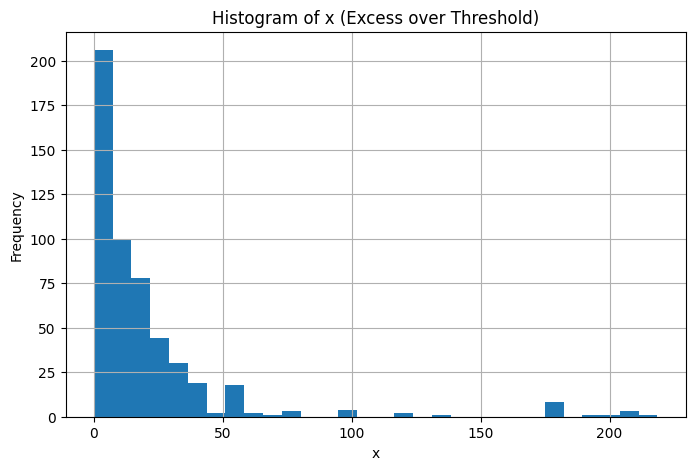

In [8]:
import matplotlib.pyplot as plt

# x > 0 のみ抽出
x_spike = train.loc[train["x"] > 0, "x"]

plt.figure(figsize=(8, 5))

plt.hist(x_spike, bins=30)

plt.title("Histogram of x (Excess over Threshold)")
plt.xlabel("x")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

In [9]:
# 閾値超過条件付きヒストリカルVaR　:要するに上位5%の価格
VaR_95_conditional = np.percentile(train.loc[train["x"] > 0, "price"], 95)
print(f"Conditional Historical VaR at 95% confidence level: {VaR_95_conditional:.2f}")

Conditional Historical VaR at 95% confidence level: 80.01


In [10]:
# 閾値超過条件付きヒストリカル条件付き期待値CVaR　:要するに上位5%の価格の平均
CVaR_95_conditional = train.loc[train["price"] > VaR_95_conditional, "price"].mean()
print(f"Conditional Historical CVaR at 95% confidence level: {CVaR_95_conditional:.2f}")

Conditional Historical CVaR at 95% confidence level: 160.71


$ x_t $はGammaでモデリングする
$$
x_t \sim \mathrm{Gamma}(\text{shape}, \text{scale})
$$

In [11]:
from scipy.stats import gamma

shape, loc, scale = gamma.fit(x_spike, floc=0)

print(shape, scale)

0.7344372173150568 28.382278138086225


0.7344372173150568 28.382278138086225


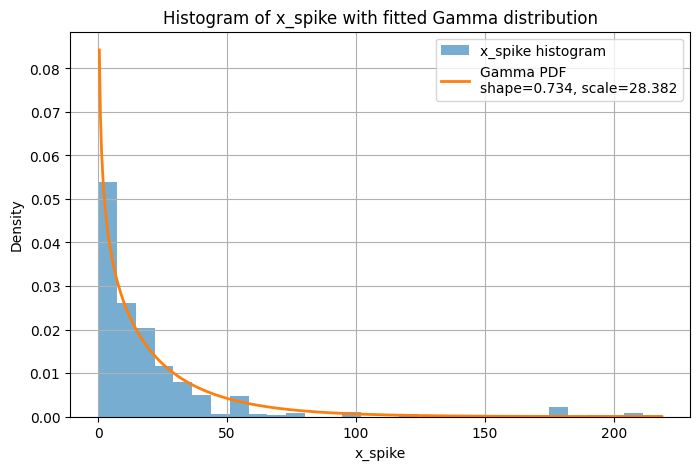

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

print(shape, scale)

# x軸
x_min = 0
x_max = x_spike.max()
x_grid = np.linspace(x_min, x_max, 500)

# Gamma分布の密度
gamma_pdf = gamma.pdf(x_grid, a=shape, scale=scale)

# ヒストグラム + Gamma分布
plt.figure(figsize=(8, 5))

plt.hist(x_spike, bins=30, density=True, alpha=0.6, label="x_spike histogram")

plt.plot(
    x_grid,
    gamma_pdf,
    linewidth=2,
    label=f"Gamma PDF\nshape={shape:.3f}, scale={scale:.3f}",
)

plt.xlabel("x_spike")
plt.ylabel("Density")
plt.title("Histogram of x_spike with fitted Gamma distribution")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
test.head()

,slot,is_holiday,price,price_scaled,u,x,date,temp,tmin,tmax,...,temp_cold,log_price,log_price_lag1,log_price_lag2,log_price_lag3,log_price_lag4,log_price_lag5,log_price_lag6,log_price_lag7,fiscal_year
datetime,,,,,,,,,,,,,,,,,,,,,
2024-04-01 17:30:00,36,False,15.00,15.00,0,0.0,2024-04-01,14.2,11.3,16.9,...,5.8,2.708050,2.751432,2.623262,2.461297,2.835564,2.853593,3.052113,2.798500,2024
2024-04-02 17:30:00,36,False,14.35,14.35,0,0.0,2024-04-02,13.6,8.8,18.3,...,6.4,2.663750,2.708050,2.751432,2.623262,2.461297,2.835564,2.853593,3.052113,2024
2024-04-03 17:30:00,36,False,16.28,16.28,0,0.0,2024-04-03,13.4,11.6,15.8,...,6.6,2.789937,2.663750,2.708050,2.751432,2.623262,2.461297,2.835564,2.853593,2024
2024-04-04 17:30:00,36,False,15.00,15.00,0,0.0,2024-04-04,15.1,11.5,18.9,...,4.9,2.708050,2.789937,2.663750,2.708050,2.751432,2.623262,2.461297,2.835564,2024
2024-04-05 17:30:00,36,False,13.09,13.09,0,0.0,2024-04-05,11.4,9.4,14.6,...,8.6,2.571849,2.708050,2.789937,2.663750,2.708050,2.751432,2.623262,2.461297,2024


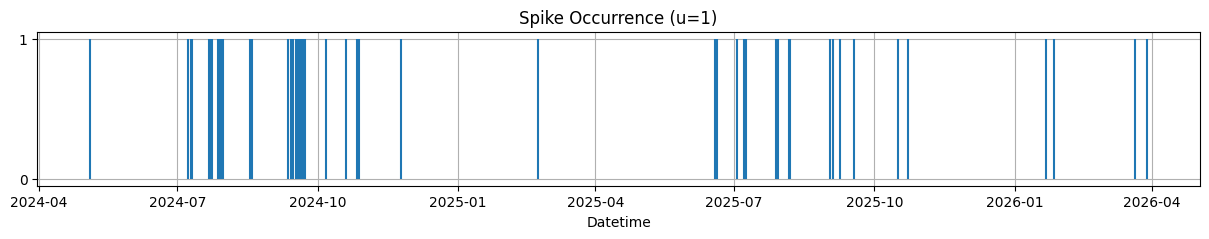

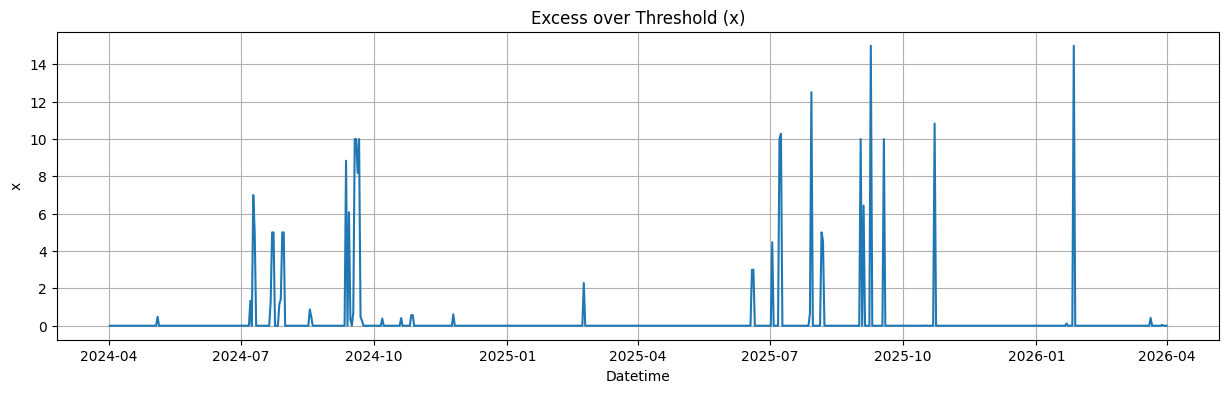

In [14]:
# -------------------------
# u : スパイク発生時刻を可視化
# -------------------------
spike_times = test.index[test["u"] == 1]

plt.figure(figsize=(15, 2))

# スパイク発生箇所に縦線
plt.vlines(
    spike_times,
    ymin=0,
    ymax=1,
)

plt.title("Spike Occurrence (u=1)")
plt.xlabel("Datetime")
plt.yticks([0, 1])
plt.grid(True)

plt.show()


# -------------------------
# x : 閾値超過量
# -------------------------
plt.figure(figsize=(15, 4))

plt.plot(test.index, test["x"])

plt.title("Excess over Threshold (x)")
plt.xlabel("Datetime")
plt.ylabel("x")
plt.grid(True)

plt.show()

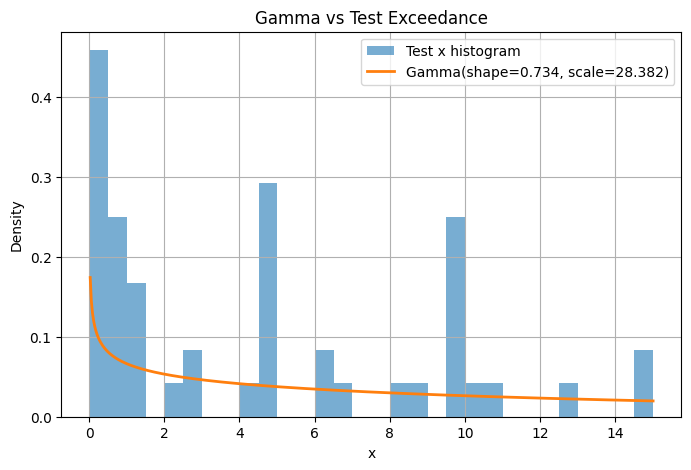

In [15]:
# x > 0 のみ抽出
x_spike = test.loc[test["x"] > 0, "x"]

# Gamma パラメータ
shape = 0.7344372173150568
scale = 28.382278138086225

# x軸
x_grid = np.linspace(0, x_spike.max(), 500)

# Gamma分布
gamma_pdf = gamma.pdf(x_grid, a=shape, scale=scale)

# 描画
plt.figure(figsize=(8, 5))

# ヒストグラム
plt.hist(x_spike, bins=30, density=True, alpha=0.6, label="Test x histogram")

# Gamma PDF
plt.plot(
    x_grid, gamma_pdf, linewidth=2, label=f"Gamma(shape={shape:.3f}, scale={scale:.3f})"
)

plt.title("Gamma vs Test Exceedance")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

Gamma分布は平均的な超過量を表現するには一定の妥当性を持つ一方、
極端なスパイクに対しては尾が軽く、巨大スパイクを十分に表現できない可能性が示唆された。

# 極値分布
一般化パレート分布
$$
F(x)=1-\left(1+\frac{\xi}{\sigma}x\right)^{-1/\xi}
$$

| $\xi$    | 型     | 意味   |
| -------- | ----- | ---- |
| $\xi = 0$ | ガンベル型 | 指数尾  |
| $\xi > 0$ | フレシェ型 | 重尾   |
| $\xi < 0$ | ワイブル型 | 上限あり |

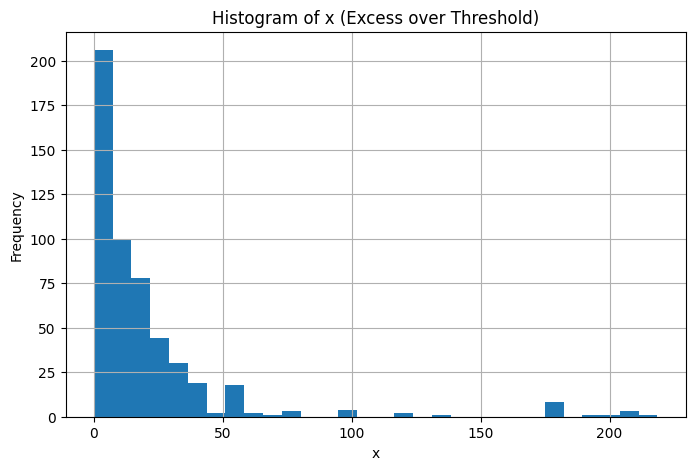

In [16]:
import matplotlib.pyplot as plt

# x > 0 のみ抽出
x_spike = train.loc[train["x"] > 0, "x"]

plt.figure(figsize=(8, 5))

plt.hist(x_spike, bins=30)

plt.title("Histogram of x (Excess over Threshold)")
plt.xlabel("x")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

In [17]:
from scipy.stats import genpareto

shape, loc, scale = genpareto.fit(x_spike, floc=0)

print("xi =", shape)
print("sigma =", scale)

xi = 0.3441256918284413
sigma = 13.59086998434256


xi = 0.3441256918284413
sigma = 13.59086998434256


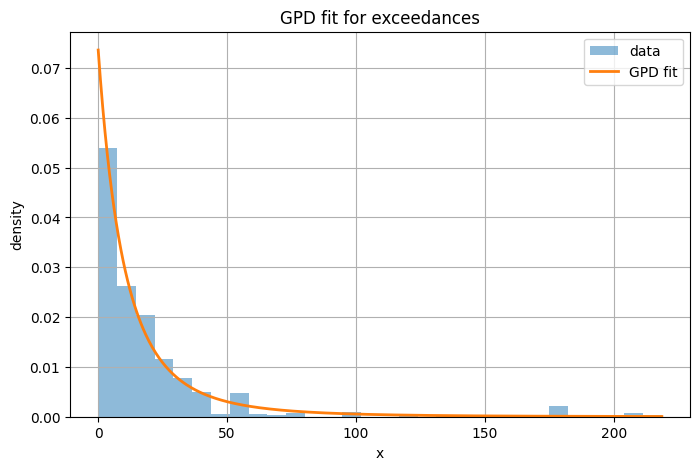

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genpareto

# 超過データ
x_spike = train.loc[train["x"] > 0, "x"]

# GPD fit
shape, loc, scale = genpareto.fit(x_spike, floc=0)

print("xi =", shape)
print("sigma =", scale)

# ヒストグラム
plt.figure(figsize=(8, 5))

plt.hist(x_spike, bins=30, density=True, alpha=0.5, label="data")

# GPD density
x = np.linspace(0, x_spike.max(), 500)

pdf = genpareto.pdf(x, c=shape, loc=0, scale=scale)

plt.plot(x, pdf, linewidth=2, label="GPD fit")

plt.xlabel("x")
plt.ylabel("density")
plt.title("GPD fit for exceedances")
plt.legend()
plt.grid(True)

plt.show()

xi = 0.3441256918284413
sigma = 13.59086998434256


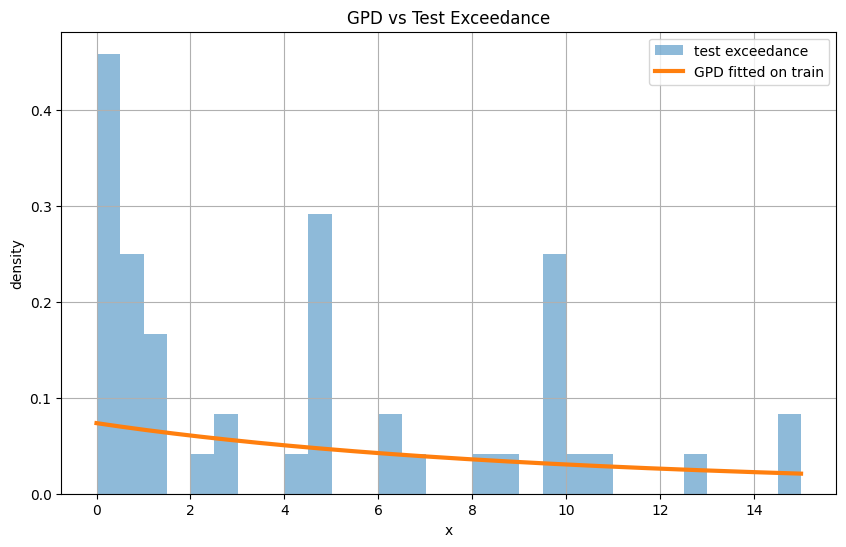

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genpareto

# -------------------------
# train exceedance
# -------------------------
x_spike_train = train.loc[train["x"] > 0, "x"]

# -------------------------
# test exceedance
# -------------------------
x_spike_test = test.loc[test["x"] > 0, "x"]

# -------------------------
# GPD fit on train
# -------------------------
shape, loc, scale = genpareto.fit(x_spike_train, floc=0)

print("xi =", shape)
print("sigma =", scale)

# -------------------------
# plot
# -------------------------
plt.figure(figsize=(10, 6))

# test histogram
plt.hist(x_spike_test, bins=30, density=True, alpha=0.5, label="test exceedance")

# fitted GPD density
x = np.linspace(0, x_spike_test.max(), 500)

pdf = genpareto.pdf(x, c=shape, loc=0, scale=scale)

plt.plot(x, pdf, linewidth=3, label="GPD fitted on train")

plt.xlabel("x")
plt.ylabel("density")
plt.title("GPD vs Test Exceedance")
plt.legend()
plt.grid(True)

plt.show()

ガンマとパレート、どちらにせよtrainデータは閾値超過価格として200などのデータが見られるのに対して、testは高くても16なのでtestデータの当てはまりが悪い。

20221年初頭と2022年を含めてGPDを推定すると、極端な超過値により尾が重く推定され、2023年以降の比較的穏やかなスパイク分布に対して過大な尾部リスクを与える。

In [ ]:
# -------------------------
# GPD fit on train
# -------------------------

# x_spike_train_normal = train.loc[(train["x"] > 0) & (train.index.year != 2022), "x"]
x_spike_train_normal = train.loc[
    (train["x"] > 0) & (train.index.year != 2021) & (train.index.year != 2022), "x"
]
shape, loc, scale = genpareto.fit(x_spike_train_normal, floc=0)

print("xi =", shape)
print("sigma =", scale)

xi = 0.034440383561444035
sigma = 12.066955676859298


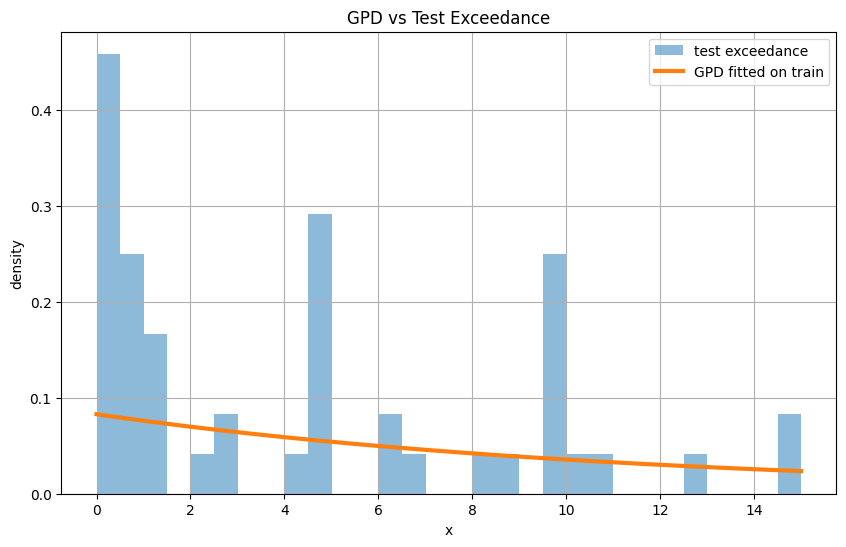

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genpareto

# -------------------------
# train exceedance
# -------------------------
x_spike_train = train.loc[train["x"] > 0, "x"]

# -------------------------
# test exceedance
# -------------------------
x_spike_test = test.loc[test["x"] > 0, "x"]

# -------------------------
# plot
# -------------------------
plt.figure(figsize=(10, 6))

# test histogram
plt.hist(x_spike_test, bins=30, density=True, alpha=0.5, label="test exceedance")

# fitted GPD density
x = np.linspace(0, x_spike_test.max(), 500)

pdf = genpareto.pdf(x, c=shape, loc=0, scale=scale)

plt.plot(x, pdf, linewidth=3, label="GPD fitted on train")

plt.xlabel("x")
plt.ylabel("density")
plt.title("GPD vs Test Exceedance")
plt.legend()
plt.grid(True)

plt.show()

0.5077573485528944 52.21170232793545


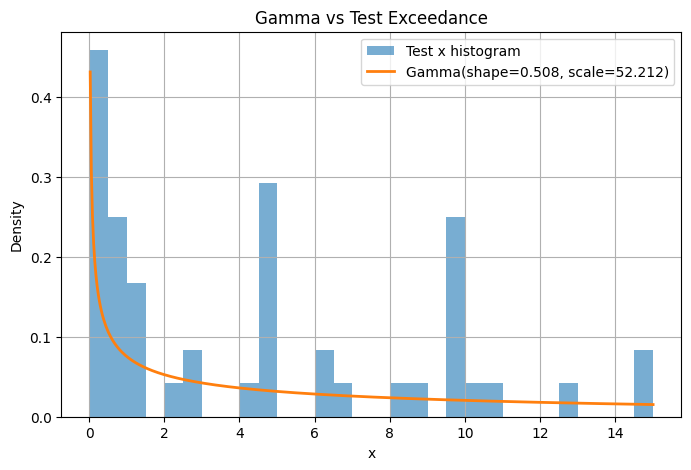

In [22]:
# x > 0 のみ抽出
x_spike = test.loc[test["x"] > 0, "x"]

x_spike_train_normal = train.loc[(train["x"] > 0) & (train.index.year != 2022), "x"]

shape, loc, scale = gamma.fit(x_spike_train_normal, floc=0)

print(shape, scale)

# x軸
x_grid = np.linspace(0, x_spike.max(), 500)

# Gamma分布
gamma_pdf = gamma.pdf(x_grid, a=shape, scale=scale)

# 描画
plt.figure(figsize=(8, 5))

# ヒストグラム
plt.hist(x_spike, bins=30, density=True, alpha=0.6, label="Test x histogram")

# Gamma PDF
plt.plot(
    x_grid, gamma_pdf, linewidth=2, label=f"Gamma(shape={shape:.3f}, scale={scale:.3f})"
)

plt.title("Gamma vs Test Exceedance")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

## Base model
$$
\mu_t = c + \sum_{j = 1}^p \alpha_j \log S_{t-j} + \beta^T x_t
$$


## Model B: Jump Model

$$
S_t=\exp{(\mu_t)} + \eta_t + 
x_t u_t
$$

$$
u_t \sim \mathrm{Bernoulli}(p_t)
$$

$$
\log \frac{p_t}{1-p_t} = \gamma_0 + \sum_{j=1}^q \gamma_j \log S_{t-j} + \omega^T z_t
$$

$$
x_t \sim \mathrm{Gamma}(\text{shape}, \text{scale})
$$

In [23]:
mu_para = pd.read_csv((PROJECT_DATA_DIR / "para/electricity/para_mu.csv"), index_col=0)
jump_para = pd.read_csv((PROJECT_DATA_DIR / "para/electricity/para_jump.csv"), index_col=0)

In [24]:
print(mu_para)
print(jump_para)

                      coef
const             0.138140
log_price_lag1    0.596653
log_price_lag2    0.085305
log_price_lag3    0.120421
log_price_lag7    0.125719
temp_centered_sq  0.000967
                       coef
const            -20.501147
log_price_lag1     3.941380
log_price_lag3     1.461131
log_price_lag7     1.035881
temp_centered_sq   0.009990
temp_hot          -0.177921
temp_cold         -0.109100


In [ ]:
# x_spike_train_normal = train.loc[(train["x"] > 0) & (train.index.year != 2022), "x"]

x_spike_train_normal = train.loc[
    (train["x"] > 0) & (train.index.year != 2021) & (train.index.year != 2022), "x"
]

shape, loc, scale = gamma.fit(x_spike_train_normal, floc=0)

print(shape, scale)

0.7484253781665222 16.695302906167115


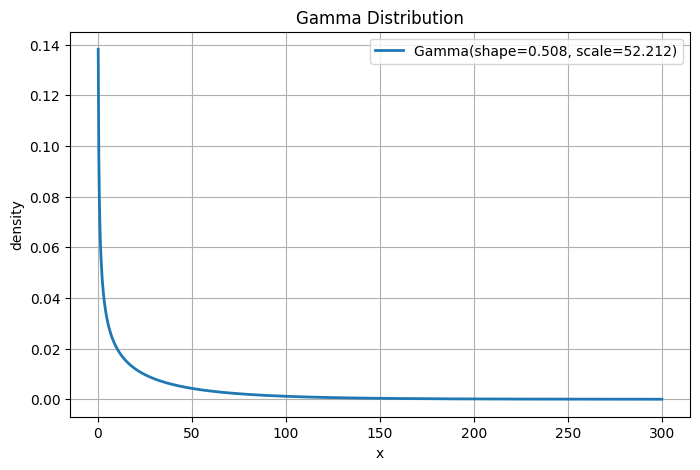

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# パラメータ
shape = 0.5077573485528944
scale = 52.21170232793545

# x軸
x = np.linspace(0, 300, 1000)

# Gamma PDF
pdf = gamma.pdf(x, a=shape, scale=scale)

# プロット
plt.figure(figsize=(8, 5))

plt.plot(x, pdf, linewidth=2, label=f"Gamma(shape={shape:.3f}, scale={scale:.3f})")

plt.xlabel("x")
plt.ylabel("density")
plt.title("Gamma Distribution")
plt.legend()
plt.grid(True)

plt.show()


In [45]:
eta_train = train.copy()
eta_train["const"] = 1.0

eta_train["mu"] = (
    eta_train["const"] * mu_para.loc["const", "coef"]
    + eta_train["log_price_lag1"] * mu_para.loc["log_price_lag1", "coef"]
    + eta_train["log_price_lag2"] * mu_para.loc["log_price_lag2", "coef"]
    + eta_train["log_price_lag3"] * mu_para.loc["log_price_lag3", "coef"]
    + eta_train["log_price_lag7"] * mu_para.loc["log_price_lag7", "coef"]
    + eta_train["temp_centered_sq"] * mu_para.loc["temp_centered_sq", "coef"]
)

eta_train["base_price"] = np.exp(eta_train["mu"])

# 非スパイク時だけで eta を推定
eta_train_non_spike = eta_train[eta_train["u"] == 0].copy()

eta_train_non_spike["eta"] = (
    eta_train_non_spike["price"] - eta_train_non_spike["base_price"]
)

sigma_eta = eta_train_non_spike["eta"].std()

sigma_eta

np.float64(3.2815889166945635)

# シミュレーション

In [46]:
import numpy as np
import pandas as pd
from scipy.stats import gamma
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -------------------------
# 0. パラメータ設定
# -------------------------

rng = np.random.default_rng(42)

mu_cols = [
    "const",
    "log_price_lag1",
    "log_price_lag2",
    "log_price_lag3",
    "log_price_lag7",
    "temp_centered_sq",
]

jump_cols = [
    "const",
    "log_price_lag1",
    "log_price_lag3",
    "log_price_lag7",
    "temp_centered_sq",
    "temp_hot",
    "temp_cold",
]

In [47]:
# -------------------------
# 1. シグモイド関数
# -------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [48]:
# -------------------------
# 2. Model B シミュレーション関数
# -------------------------
def simulate_model_b(
    df,
    mu_para,
    jump_para,
    shape,
    scale,
    sigma_eta,
    target_col="price",
    n_sim=1,
    random_seed=42,
):
    rng = np.random.default_rng(random_seed)

    sim_results = []

    for sim_id in range(n_sim):
        sim_df = df.copy()

        required_cols = [
            target_col,
            "log_price_lag1",
            "log_price_lag2",
            "log_price_lag3",
            "log_price_lag7",
            "temp_centered_sq",
            "temp_hot",
            "temp_cold",
        ]

        sim_df = sim_df[required_cols].dropna().copy()

        # const
        sim_df["const"] = 1.0

        # -------------------------
        # mu_t
        # -------------------------
        mu = np.zeros(len(sim_df))

        for col in mu_cols:
            mu += sim_df[col].values * float(mu_para.loc[col, "coef"])

        sim_df["mu"] = mu

        # -------------------------
        # p_t
        # -------------------------
        logit_p = np.zeros(len(sim_df))

        for col in jump_cols:
            logit_p += sim_df[col].values * float(jump_para.loc[col, "coef"])

        sim_df["p_jump"] = sigmoid(logit_p)

        # -------------------------
        # u_t ~ Bernoulli(p_t)
        # -------------------------
        sim_df["u_sim"] = rng.binomial(1, sim_df["p_jump"].values)

        # -------------------------
        # X_t ~ Gamma(shape, scale)
        # -------------------------
        sim_df["jump_size"] = gamma.rvs(
            a=shape,
            scale=scale,
            size=len(sim_df),
            random_state=rng,
        )

        # -------------------------
        # eta_t ~ N(0, sigma_eta^2)
        # -------------------------
        sim_df["eta"] = rng.normal(
            loc=0,
            scale=sigma_eta,
            size=len(sim_df),
        )

        # -------------------------
        # S_t = exp(mu_t) + eta_t + X_t u_t
        # -------------------------
        sim_df["sim_price"] = (
            np.exp(sim_df["mu"]) + sim_df["eta"] + sim_df["jump_size"] * sim_df["u_sim"]
        )

        # 負価格防止
        sim_df["sim_price"] = np.maximum(
            sim_df["sim_price"],
            0.01,
        )

        sim_df["sim_id"] = sim_id

        sim_results.append(sim_df)

    return pd.concat(sim_results)

In [49]:
# -------------------------
# 3. 評価関数
# -------------------------
def evaluate_simulation(
    sim_df,
    target_col="price",
    pred_col="sim_price",
):

    y_true = sim_df[target_col]
    y_pred = sim_df[pred_col]

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    var_95 = np.quantile(y_pred, 0.95)
    cvar_95 = y_pred[y_pred >= var_95].mean()

    result = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "actual_mean": y_true.mean(),
        "sim_mean": y_pred.mean(),
        "actual_max": y_true.max(),
        "sim_max": y_pred.max(),
        "actual_VaR95": np.quantile(y_true, 0.95),
        "sim_VaR95": var_95,
        "actual_CVaR95": (y_true[y_true >= np.quantile(y_true, 0.95)].mean()),
        "sim_CVaR95": cvar_95,
        "actual_spike_count": (y_true > 25).sum(),
        "sim_spike_count": (y_pred > 25).sum(),
    }

    return pd.Series(result)

In [50]:
print(mu_para)
print(jump_para)

                      coef
const             0.138140
log_price_lag1    0.596653
log_price_lag2    0.085305
log_price_lag3    0.120421
log_price_lag7    0.125719
temp_centered_sq  0.000967
                       coef
const            -20.501147
log_price_lag1     3.941380
log_price_lag3     1.461131
log_price_lag7     1.035881
temp_centered_sq   0.009990
temp_hot          -0.177921
temp_cold         -0.109100


In [ ]:
# x_spike_train_normal = train.loc[(train["x"] > 0) & (train.index.year != 2022), "x"]

x_spike_train_normal = train.loc[
    (train["x"] > 0) & (train.index.year != 2021) & (train.index.year != 2022), "x"
]

shape, loc, scale = gamma.fit(x_spike_train_normal, floc=0)

print(shape, scale)

0.7484253781665222 16.695302906167115


In [53]:
print(shape, scale)
print(sigma_eta)

0.7484253781665222 16.695302906167115
3.2815889166945635


In [54]:
# -------------------------
# 4. test データでシミュレーション
# -------------------------
sim_b_test = simulate_model_b(
    df=test,
    mu_para=mu_para,
    jump_para=jump_para,
    shape=shape,
    scale=scale,
    sigma_eta=sigma_eta,
    target_col="price",
    n_sim=1,
    random_seed=42,
)

eval_b_test = evaluate_simulation(
    sim_b_test,
    target_col="price",
    pred_col="sim_price",
)

eval_b_test

MSE                    96.240636
RMSE                    9.810231
MAE                     5.468168
actual_mean            17.005630
sim_mean               20.202293
actual_max             40.000000
sim_max               100.662719
actual_VaR95           22.478500
sim_VaR95              37.811307
actual_CVaR95          30.234054
sim_CVaR95             54.827687
actual_spike_count     29.000000
sim_spike_count       117.000000
dtype: float64

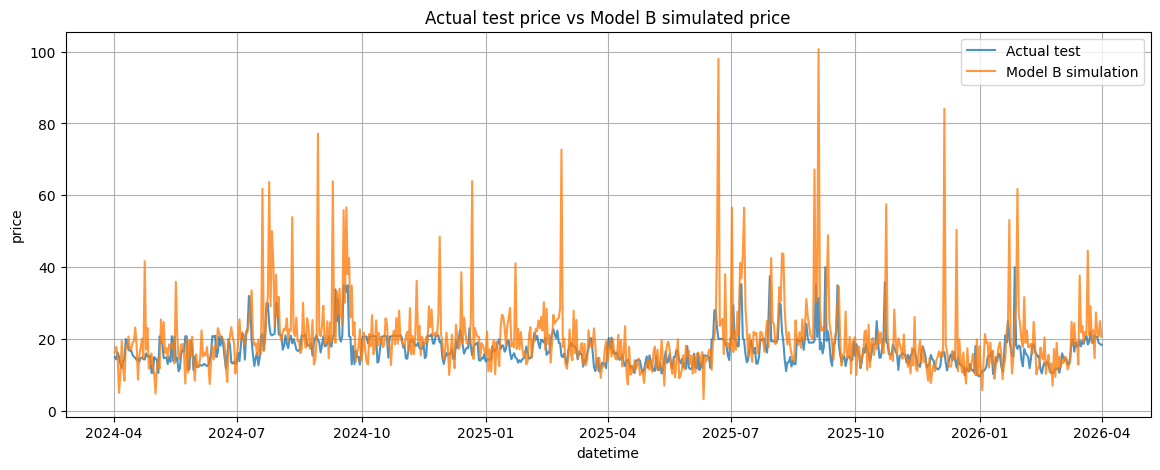

In [55]:
# -------------------------
# 5. 時系列プロット
# -------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    sim_b_test.index,
    sim_b_test["price"],
    label="Actual test",
    alpha=0.8,
)

plt.plot(
    sim_b_test.index,
    sim_b_test["sim_price"],
    label="Model B simulation",
    alpha=0.8,
)

plt.legend()
plt.title("Actual test price vs Model B simulated price")

plt.xlabel("datetime")
plt.ylabel("price")
plt.grid(True)

plt.show()

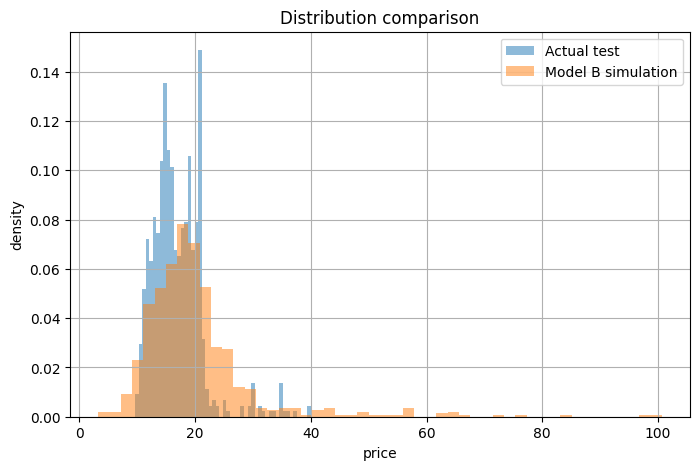

In [56]:
# -------------------------
# 6. ヒストグラム比較
# -------------------------
plt.figure(figsize=(8, 5))

plt.hist(
    sim_b_test["price"],
    bins=50,
    alpha=0.5,
    density=True,
    label="Actual test",
)

plt.hist(
    sim_b_test["sim_price"],
    bins=50,
    alpha=0.5,
    density=True,
    label="Model B simulation",
)

plt.legend()

plt.title("Distribution comparison")

plt.xlabel("price")
plt.ylabel("density")

plt.grid(True)

plt.show()

In [57]:
eval_b_test

MSE                    96.240636
RMSE                    9.810231
MAE                     5.468168
actual_mean            17.005630
sim_mean               20.202293
actual_max             40.000000
sim_max               100.662719
actual_VaR95           22.478500
sim_VaR95              37.811307
actual_CVaR95          30.234054
sim_CVaR95             54.827687
actual_spike_count     29.000000
sim_spike_count       117.000000
dtype: float64

trainのデータは2020年と2022年で超高騰が起きているのでパラメータの推定が高い

ので暫定的に抑えめのパラメータを設定してシミュレーションする

In [58]:
from scipy.stats import gamma

x_spike_normal = train.loc[(train["x"] > 0) & (train["x"] <= 20), "x"]

shape_normal, loc_normal, scale_normal = gamma.fit(x_spike_normal, floc=0)

print(shape_normal, scale_normal)

1.2387770660726218 6.393809413396546


In [59]:
# -------------------------
# 4. test データでシミュレーション
# -------------------------
sim_b_test = simulate_model_b(
    df=test,
    mu_para=mu_para,
    jump_para=jump_para,
    shape=shape_normal,
    scale=scale_normal,
    sigma_eta=sigma_eta,
    target_col="price",
    n_sim=1,
    random_seed=42,
)

eval_b_test = evaluate_simulation(
    sim_b_test,
    target_col="price",
    pred_col="sim_price",
)

eval_b_test

MSE                    40.351903
RMSE                    6.352315
MAE                     4.563601
actual_mean            17.005630
sim_mean               19.194883
actual_max             40.000000
sim_max                60.403729
actual_VaR95           22.478500
sim_VaR95              32.963339
actual_CVaR95          30.234054
sim_CVaR95             37.906111
actual_spike_count     29.000000
sim_spike_count       110.000000
dtype: float64

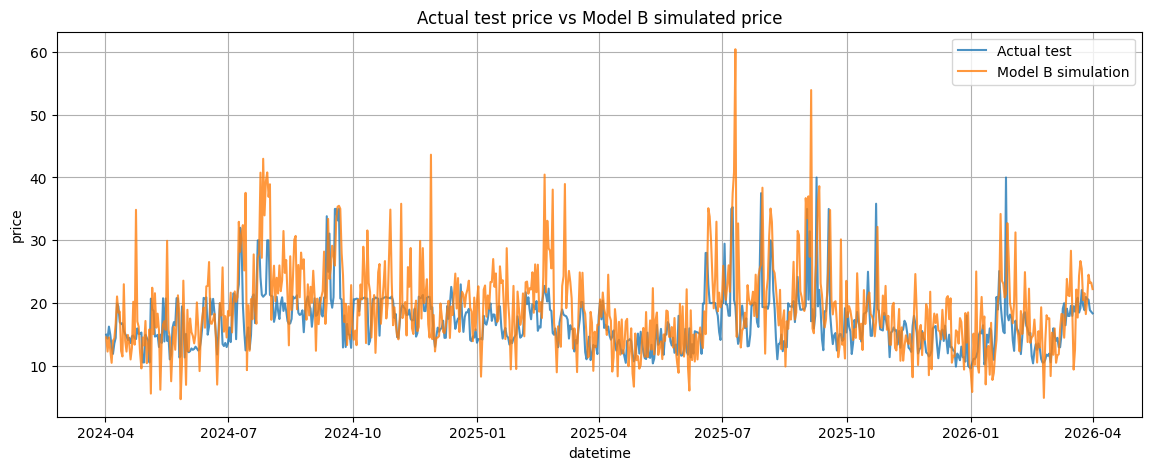

In [40]:
# -------------------------
# 5. 時系列プロット
# -------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    sim_b_test.index,
    sim_b_test["price"],
    label="Actual test",
    alpha=0.8,
)

plt.plot(
    sim_b_test.index,
    sim_b_test["sim_price"],
    label="Model B simulation",
    alpha=0.8,
)

plt.legend()
plt.title("Actual test price vs Model B simulated price")

plt.xlabel("datetime")
plt.ylabel("price")
plt.grid(True)

plt.show()

これはテストデータの挙動を知っているからできる所業なので、超過価格のモデリングはしっかりやる必要がある。

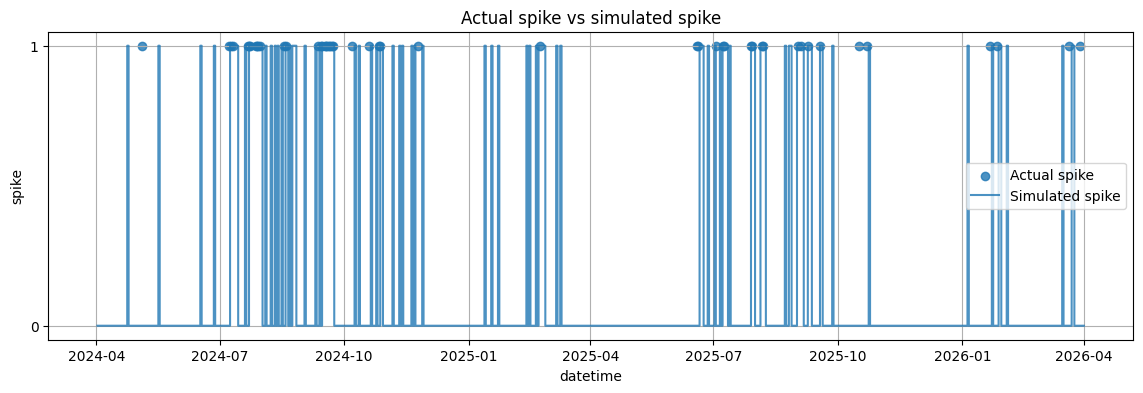

In [41]:
# -------------------------
# 真のスパイク時刻
# -------------------------
spike_times = test.index[test["u"] == 1]

# -------------------------
# シミュレーション側のみ25以上で判定
# -------------------------
threshold = 25

sim_b_test["sim_spike"] = (sim_b_test["sim_price"] >= threshold).astype(int)

# -------------------------
# プロット
# -------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))

# 真のスパイク（青）
plt.scatter(
    spike_times,
    [1] * len(spike_times),
    label="Actual spike",
    alpha=0.8,
)

# シミュレーションスパイク（オレンジ）
plt.step(
    sim_b_test.index,
    sim_b_test["sim_spike"],
    where="post",
    label="Simulated spike",
    alpha=0.8,
)

plt.yticks([0, 1])

plt.title("Actual spike vs simulated spike")
plt.xlabel("datetime")
plt.ylabel("spike")

plt.grid(True)
plt.legend()

plt.show()

In [42]:
from sklearn.metrics import confusion_matrix

# -------------------------
# シミュレーション側のスパイク判定
# -------------------------
threshold = 25

sim_b_test["sim_spike"] = (sim_b_test["sim_price"] >= threshold).astype(int)

# -------------------------
# 真値（u）
# -------------------------
y_true = test.loc[sim_b_test.index, "u"]

# -------------------------
# 予測値
# -------------------------
y_pred = sim_b_test["sim_spike"]

# -------------------------
# 混同行列
# -------------------------
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[601  81]
 [ 19  29]]
